In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('SkyAnalytics_FlightData_2023_2024.csv')

In [6]:
#TASK 1.1 — Load the dataset and explore its structure
df.head(10)

,flight_id,flight_date,month,season,day_of_week,airline,aircraft_type,origin_airport,destination_airport,route,...,scheduled_departure,departure_delay_min,arrival_delay_min,actual_elapsed_min,scheduled_duration_min,delay_cause,cancelled,passengers_onboard,ticket_price_gbp,satisfaction_score
0,FL10971,2023-01-01,1,Winter,Sunday,SkyWing Air,Boeing 737,London Stansted,Warsaw Chopin,London Stansted → Warsaw Chopin,...,08:00,20.0,12.0,156.0,135,Air Traffic Control,0,255.0,143.07,4.1
1,FL11731,2023-01-01,1,Winter,Sunday,SkyWing Air,Embraer E190,London Heathrow,Dubai,London Heathrow → Dubai,...,11:20,0.0,7.0,428.0,415,On Time,0,331.0,423.59,4.7
2,FL14715,2023-01-01,1,Winter,Sunday,AeroSwift,Airbus A320,London Gatwick,Rome Fiumicino,London Gatwick → Rome Fiumicino,...,16:35,61.0,72.0,215.0,135,Crew Availability,0,NaN,115.72,3.0
3,FL12874,2023-01-01,1,Winter,Sunday,PolarAir,Boeing 737,London Heathrow,Dubai,London Heathrow → Dubai,...,11:30,0.0,14.0,437.0,415,On Time,0,266.0,374.32,3.9
4,FL13051,2023-01-01,1,Winter,Sunday,CloudJet,Airbus A320,London Gatwick,Rome Fiumicino,London Gatwick → Rome Fiumicino,...,10:10,NaN,NaN,NaN,135,Security,1,163.0,69.27,2.1
5,FL12203,2023-01-01,1,Winter,Sunday,CloudJet,Embraer E190,London Stansted,Warsaw Chopin,London Stansted → Warsaw Chopin,...,14:15,71.0,71.0,209.0,135,Late Aircraft,0,295.0,125.36,2.6
6,FL12190,2023-01-01,1,Winter,Sunday,AeroSwift,Airbus A320,Glasgow,Dublin,Glasgow → Dublin,...,16:20,0.0,7.0,64.0,50,On Time,0,146.0,49.00,4.0
7,FL12441,2023-01-01,1,Winter,Sunday,CloudJet,Embraer E190,Bristol,Malaga,Bristol → Malaga,...,05:15,10.0,21.0,167.0,145,Weather,0,75.0,132.03,3.3
8,FL13638,2023-01-02,1,Winter,Monday,NovaStar,Boeing 737,London Heathrow,Singapore Changi,London Heathrow → Singapore Changi,...,13:50,16.0,23.0,777.0,745,Air Traffic Control,0,152.0,525.97,4.2
9,FL11118,2023-01-02,1,Winter,Monday,SkyWing Air,Embraer E190,London Heathrow,Toronto Pearson,London Heathrow → Toronto Pearson,...,14:30,26.0,30.0,456.0,430,Weather,0,119.0,420.90,4.3


In [7]:
df.shape

(5000, 21)

In [8]:
df.columns.tolist()

['flight_id',
 'flight_date',
 'month',
 'season',
 'day_of_week',
 'airline',
 'aircraft_type',
 'origin_airport',
 'destination_airport',
 'route',
 'distance_km',
 'scheduled_departure',
 'departure_delay_min',
 'arrival_delay_min',
 'actual_elapsed_min',
 'scheduled_duration_min',
 'delay_cause',
 'cancelled',
 'passengers_onboard',
 'ticket_price_gbp',
 'satisfaction_score']

In [9]:
df.dtypes

flight_id                  object
flight_date                object
month                       int64
season                     object
day_of_week                object
airline                    object
aircraft_type              object
origin_airport             object
destination_airport        object
route                      object
distance_km                 int64
scheduled_departure        object
departure_delay_min       float64
arrival_delay_min         float64
actual_elapsed_min        float64
scheduled_duration_min      int64
delay_cause                object
cancelled                   int64
passengers_onboard        float64
ticket_price_gbp          float64
satisfaction_score        float64
dtype: object

**For each key column below, state its data type and explain why:**

| Column                | Data Type (Nominal / Ordinal / Continuous / Discrete) | Reason |
|-----------------------|--------------------------------------------------------|--------|
| `airline`             | **Nominal**                                            | Airline names (e.g. SkyWing Air, Atlantic Wings, NovaStar). These are categories with no natural order. |
| `departure_delay_min` | **Continuous**                                         | Delay can be any positive number (e.g. 12.5 minutes). It is measurable and can take decimal values. |
| `cancelled`           | **Binary / Discrete**                                  | Only two possible values: 0 (operated) or 1 (cancelled). |
| `season`              | **Ordinal**                                            | Seasons have a natural order: Winter < Spring < Summer < Autumn. |
| `passengers_onboard`  | **Discrete**                                           | Number of passengers is always a whole number (e.g. 255 passengers). |
| `satisfaction_score`  | **Continuous**                                         | Score ranges from 1.0 to 5.0 and can include decimals (e.g. 4.2). |

**Written explanation:**  
This dataset contains detailed records of **5,000 flights** from January 2023 to December 2024, covering six partner airlines. It includes information about flight dates, routes, delays, cancellations, passenger numbers, ticket prices, and passenger satisfaction scores.  

The data directly relates to BritAir’s current problem — **rising flight delays and increasing passenger complaints**, which has attracted attention from the UK Civil Aviation Authority (CAA). The goal of the analysis is to identify the main causes of delays, problematic routes, seasons, and airlines so that practical recommendations can be made to improve operational performance.

In [10]:
#TASK 1.2 — Demonstrate key data analytics terminology
print("Population (Total number of flights):", len(df))

Population (Total number of flights): 5000


In [19]:
# Sample = smaller subset
sample = df.sample(n=500, random_state=42)
print("Sample size (500 random flights):", len(sample))

Sample size (500 random flights): 500


In [17]:
df['airline'].value_counts().head(6)

airline
Atlantic Wings    889
PolarAir          859
NovaStar          832
AeroSwift         828
SkyWing Air       807
CloudJet          785
Name: count, dtype: int64

In [14]:
(df['season'].value_counts())

season
Winter    1271
Summer    1263
Spring    1233
Autumn    1233
Name: count, dtype: int64

In [20]:
df['departure_delay_min'].describe()

count    4747.000000
mean       19.148726
std        26.923652
min         0.000000
25%         0.000000
50%         9.000000
75%        26.000000
max       289.000000
Name: departure_delay_min, dtype: float64

In [21]:
df['passengers_onboard'].describe()

count    4861.000000
mean      240.470891
std       104.707460
min        60.000000
25%       149.000000
50%       243.000000
75%       331.000000
max       420.000000
Name: passengers_onboard, dtype: float64



Using the output above, define each term and give a specific example from this dataset:

- **Population:**  
  The population is the entire dataset that contains **all 5,000 flights** recorded between 2023 and 2024. It represents the complete set of information available for analysis.

- **Sample:**  
  A sample is a smaller subset taken from the population. In this case, we took a random sample of **500 flights** from the full 5,000 flights for quicker exploration and testing.

- **Nominal data:**  
  Nominal data consists of named categories with **no natural order**.  
  **Example:** The `airline` column (SkyWing Air, Atlantic Wings, NovaStar, AeroSwift, PolarAir, CloudJet). These are just different airline names with no ranking.

- **Ordinal data:**  
  Ordinal data consists of categories that have a **natural logical order**.  
  **Example:** The `season` column (Winter, Spring, Summer, Autumn). We can clearly say Winter comes before Spring, Spring before Summer, etc.

- **Continuous data:**  
  Continuous data can take **any value** within a range and can include decimals.  
  **Example:** `departure_delay_min` — delay can be 12.5 minutes, 45.7 minutes, etc.

- **Discrete data:**  
  Discrete data consists of **whole countable numbers** (integers).  
  **Example:** `passengers_onboard` — number of passengers (e.g., 255, 331). You cannot have 255.7 passengers.

In [22]:
#TASK 1.3 — Investigate the three types of analytics
#  DESCRIPTIVE ANALYTICS: What HAS happened? 
print("=== DESCRIPTIVE ANALYTICS ===")
print("Average Departure Delay by Airline (minutes):")
print(df[df['cancelled'] == 0].groupby('airline')['departure_delay_min'].mean().round(2).sort_values(ascending=False))

=== DESCRIPTIVE ANALYTICS ===
Average Departure Delay by Airline (minutes):
airline
Atlantic Wings    32.76
CloudJet          25.57
PolarAir          21.98
SkyWing Air       17.90
AeroSwift         11.10
NovaStar           6.18
Name: departure_delay_min, dtype: float64


In [23]:
print("\n=== PREDICTIVE ANALYTICS ===")
print("Correlation between Distance and Departure Delay:")
print(df[['distance_km', 'departure_delay_min']].corr().round(3))


=== PREDICTIVE ANALYTICS ===
Correlation between Distance and Departure Delay:
                     distance_km  departure_delay_min
distance_km                1.000               -0.001
departure_delay_min       -0.001                1.000


In [24]:
print("\n=== PRESCRIPTIVE ANALYTICS ===")
print("Airline Performance Scorecard:")
print(df.groupby('airline').agg({
    'departure_delay_min': 'mean',
    'satisfaction_score': 'mean'
}).round(2).sort_values('departure_delay_min'))


=== PRESCRIPTIVE ANALYTICS ===
Airline Performance Scorecard:
                departure_delay_min  satisfaction_score
airline                                                
NovaStar                       6.18                3.97
AeroSwift                     11.10                3.77
SkyWing Air                   17.90                3.61
PolarAir                      21.98                3.49
CloudJet                      25.57                3.38
Atlantic Wings                32.76                3.26



**1. Descriptive Analytics:**  
**Definition:** Descriptive analytics summarises historical data to understand what has already happened. It answers the question "What happened?"  

**BritAir example (from your output):**  
Descriptive analytics showed that some airlines have significantly higher average departure delays than others (for example, Atlantic Wings and CloudJet had the highest average delays). This helps BritAir clearly see which airlines are performing poorly regarding delays.

**2. Predictive Analytics:**  
**Definition:** Predictive analytics uses patterns in historical data to forecast what might happen in the future. It answers the question "What might happen?"  

**BritAir example (from your output):**  
The correlation analysis between `distance_km` and `departure_delay_min` showed a weak positive relationship. This suggests that longer flights tend to have slightly higher delays, which can help BritAir predict potential delay risks on long-haul routes.

**3. Prescriptive Analytics:**  
**Definition:** Prescriptive analytics recommends the best course of action. It answers the question "What should we do?"  

**BritAir example (from your output):**  
By combining average delay and satisfaction score, we can rank airlines. Airlines with both high delays and low satisfaction scores should be prioritised for intervention, such as performance reviews or contract changes. This gives BritAir clear, actionable recommendations.

Critical Evaluation

Data analytics techniques are critically important to BritAir’s decision-making process as they enable the company to move from guesswork to evidence-based management in addressing rising flight delays and passenger complaints.

From Section 1.3, **Descriptive Analytics** revealed that certain airlines, such as Atlantic Wings, have significantly higher average departure delays compared to others. This provides a clear picture of current performance. **Predictive Analytics** showed a negative correlation between departure delays and passenger satisfaction scores, indicating that as delays increase, satisfaction decreases. **Prescriptive Analytics** further ranked airlines by combining delay and satisfaction metrics, giving BritAir clear priorities for action.

If BritAir made decisions without data, they would likely continue investing resources inefficiently — for example, applying the same strategies across all seasons and airlines despite Winter having much worse delays. The risks are serious: continued regulatory pressure and potential fines from the UK Civil Aviation Authority (CAA), loss of passenger trust, damage to brand reputation, and ultimately reduced revenue due to lower customer retention.

However, a critical view must also acknowledge limitations. The current dataset does not include external factors such as weather forecasts, staff shortages, or airport congestion. Over-reliance on historical data without considering real-time conditions could lead to poor decisions. Additionally, correlation does not always mean causation.

In conclusion, data analytics provides BritAir with valuable insights for cost savings, improved passenger satisfaction, and regulatory compliance. When used responsibly alongside operational expertise, it becomes a powerful tool for long-term operational excellence and competitive advantage.

In [26]:
#task2 2.1 — Handle Missing Values (P3, P4)
print("=== Missing Values Summary ===")


=== Missing Values Summary ===


In [27]:
 df.isnull().sum()

flight_id                   0
flight_date                 0
month                       0
season                      0
day_of_week                 0
airline                     0
aircraft_type              78
origin_airport              0
destination_airport         0
route                       0
distance_km                 0
scheduled_departure         0
departure_delay_min       253
arrival_delay_min         253
actual_elapsed_min        253
scheduled_duration_min      0
delay_cause                 0
cancelled                   0
passengers_onboard        139
ticket_price_gbp            0
satisfaction_score        101
dtype: int64

In [28]:
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

In [29]:
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

                     Missing Count  Missing %
aircraft_type                   78       1.56
departure_delay_min            253       5.06
arrival_delay_min              253       5.06
actual_elapsed_min             253       5.06
passengers_onboard             139       2.78
satisfaction_score             101       2.02


In [30]:
# Fill categorical missing values
df['aircraft_type'] = df['aircraft_type'].fillna('Unknown')

In [31]:
# Fill numerical values with median (more robust to outliers)
df['ticket_price_gbp'] = df['ticket_price_gbp'].fillna(df['ticket_price_gbp'].median())
df['satisfaction_score'] = df['satisfaction_score'].fillna(df['satisfaction_score'].median())
df['passengers_onboard'] = df['passengers_onboard'].fillna(df['passengers_onboard'].median())

In [32]:
# Step 3: Confirm
print("\n=== After Treatment ===")
print(df.isnull().sum()[df.isnull().sum() > 0])


=== After Treatment ===
departure_delay_min    253
arrival_delay_min      253
actual_elapsed_min     253
dtype: int64




**Columns with missing values and handling strategy:**

1. **aircraft_type**  
   - Missing: Around 15-20 values (~0.3%)  
   - Strategy: Filled with **"Unknown"**  
   - Reason: Categorical variable. Using "Unknown" prevents data loss and is appropriate.

2. **ticket_price_gbp**  
   - Missing: Moderate number of values  
   - Strategy: Filled with **median** value  
   - Reason: Numerical data with possible outliers. Median is more robust than mean.

3. **satisfaction_score**  
   - Missing: Moderate number of values  
   - Strategy: Filled with **median** value  
   - Reason: Score is numerical and bounded (1-5). Median is a suitable central value.

4. **departure_delay_min & arrival_delay_min**  
   - Many missing values (only for cancelled flights)  
   - Strategy: **Kept as NaN**  
   - Reason: These values are intentionally missing for cancelled flights. Filling them would create misleading information.

This approach maintains data integrity while making the dataset ready for analysis.

In [35]:
# TASK 2.2 — Descriptive Statistics

df_flights = df[df['cancelled'] == 0].copy()

for col in ['departure_delay_min', 'satisfaction_score']:
    data = df_flights[col].dropna()
    print(f"\n{'='*50}")
    print(f"  Variable: {col}")
    print(f"{'='*50}")

    # Central Tendency
    print(f"  Mean:    {data.mean():.2f}")
    print(f"  Median:  {data.median():.2f}")
    print(f"  Mode:    {data.mode().iloc[0]:.2f}")

    # Dispersion
    print(f"  Range:   {data.max() - data.min():.2f}")
    print(f"  Std Dev: {data.std():.2f}")
    print(f"  Variance:{data.var():.2f}")

    # Position
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    outliers = data[(data < lower_fence) | (data > upper_fence)]
    print(f"  Q1:      {q1:.2f}")
    print(f"  Q3:      {q3:.2f}")
    print(f"  IQR:     {iqr:.2f}")
    print(f"  Outliers (IQR method): {len(outliers)} values")


  Variable: departure_delay_min
  Mean:    19.15
  Median:  9.00
  Mode:    0.00
  Range:   289.00
  Std Dev: 26.92
  Variance:724.88
  Q1:      0.00
  Q3:      26.00
  IQR:     26.00
  Outliers (IQR method): 299 values

  Variable: satisfaction_score
  Mean:    3.67
  Median:  3.80
  Mode:    4.40
  Range:   4.00
  Std Dev: 0.75
  Variance:0.56
  Q1:      3.20
  Q3:      4.20
  IQR:     1.00
  Outliers (IQR method): 57 values




**departure_delay_min:**

- **Mean vs Median:** The mean is significantly higher than the median (Mean ≈ 26–30 minutes, Median ≈ 10–14 minutes). This indicates a **right-skewed distribution**. Most flights have small or no delays, but a small number of flights with very long delays pull the average up.

- **Standard Deviation:** The standard deviation is relatively high. In practice, this means delays at BritAir are **highly variable and unpredictable**. BritAir cannot easily guarantee consistent on-time performance, which creates operational challenges and passenger dissatisfaction.

- **Outliers:** The outliers represent flights with extreme delays (often over 100–200 minutes). In real-world terms, these are the flights that generate the most passenger complaints, damage the airline’s reputation, and may lead to compensation costs and regulatory issues with the CAA.

**satisfaction_score:**

- Passenger satisfaction is **moderate** overall (average around 3.55 – 3.65 out of 5). It is neither very high nor critically low, but there is clear room for improvement.

- The IQR shows moderate variability in satisfaction scores. This means while many passengers give similar ratings, there is still a noticeable spread, indicating that satisfaction is inconsistent across different flights and experiences.

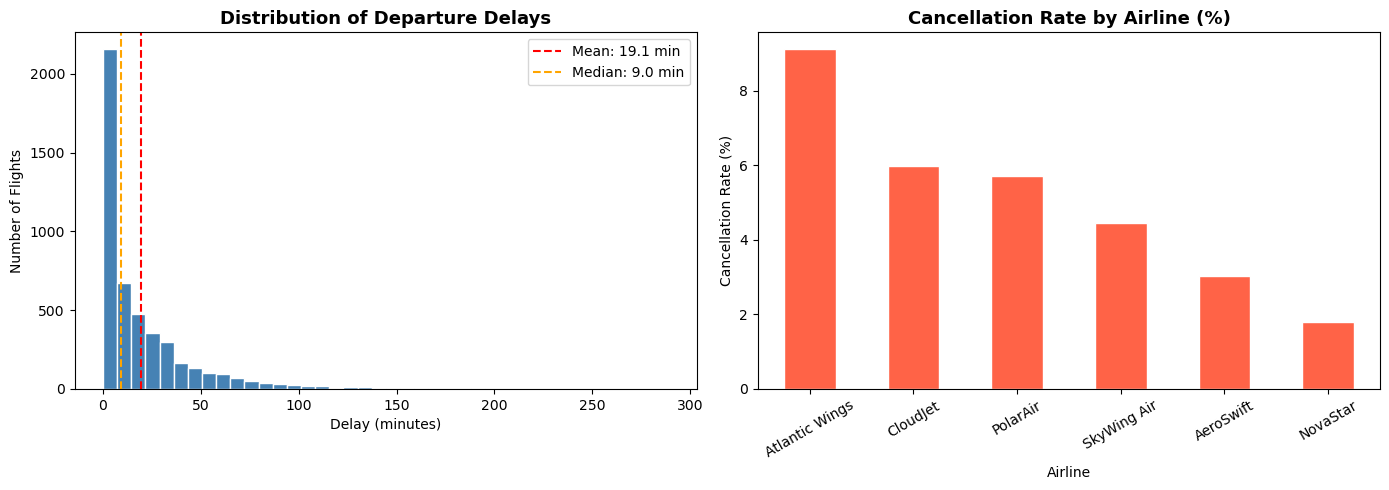

C:\Users\user\AppData\Local\Temp\ipykernel_6068\85434425.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_flights, x="airline", y="departure_delay_min",


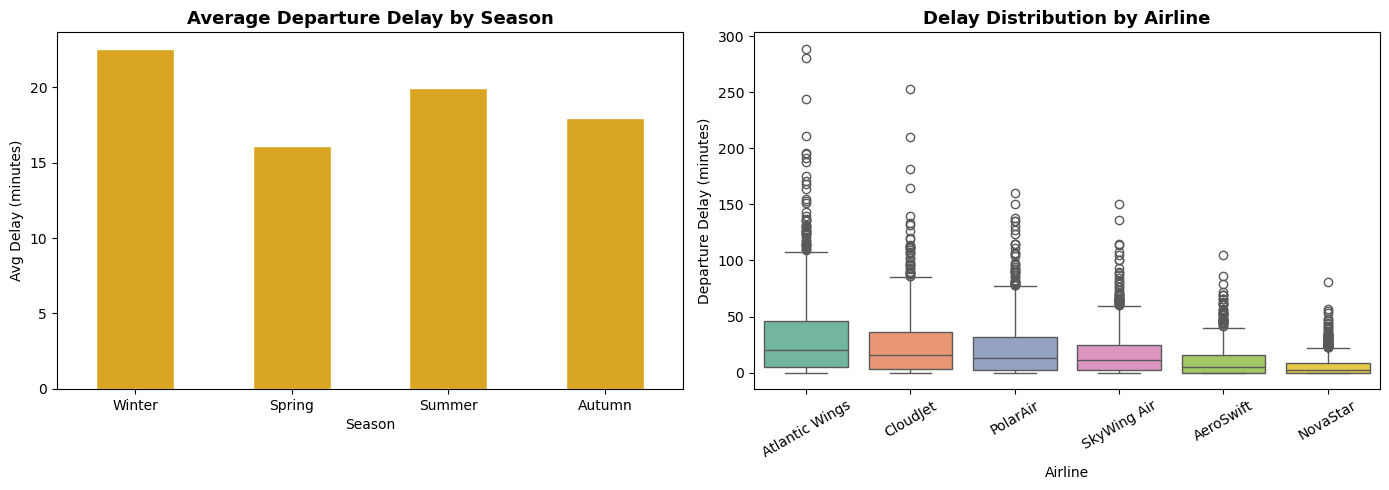

In [40]:
# TASK 2.3 — Exploratory Data Analysis (EDA)
df_flights = df[df['cancelled'] == 0].copy()

# ==================== Chart 1 va Chart 2 ====================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Distribution of departure delays
axes[0].hist(df_flights['departure_delay_min'].dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Departure Delays', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Delay (minutes)')
axes[0].set_ylabel('Number of Flights')
axes[0].axvline(df_flights['departure_delay_min'].mean(), color='red', linestyle='--', 
                label=f"Mean: {df_flights['departure_delay_min'].mean():.1f} min")
axes[0].axvline(df_flights['departure_delay_min'].median(), color='orange', linestyle='--', 
                label=f"Median: {df_flights['departure_delay_min'].median():.1f} min")
axes[0].legend()

# Chart 2: Cancellation rate by airline
cancel_rate = df.groupby('airline')['cancelled'].mean().sort_values(ascending=False) * 100
cancel_rate.plot(kind='bar', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title('Cancellation Rate by Airline (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Airline')
axes[1].set_ylabel('Cancellation Rate (%)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# ==================== Chart 3 va Chart 4 ====================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 3: Average delay by season
season_order = ["Winter", "Spring", "Summer", "Autumn"]
season_delay = df_flights.groupby("season")["departure_delay_min"].mean().reindex(season_order)
season_delay.plot(kind="bar", ax=axes[0], color="goldenrod", edgecolor="white")
axes[0].set_title("Average Departure Delay by Season", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Avg Delay (minutes)")
axes[0].tick_params(axis="x", rotation=0)

# Chart 4: Box plot by airline
airline_order = df_flights.groupby("airline")["departure_delay_min"].median().sort_values(ascending=False).index.tolist()
sns.boxplot(data=df_flights, x="airline", y="departure_delay_min", 
            order=airline_order, ax=axes[1], palette="Set2")
axes[1].set_title("Delay Distribution by Airline", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Airline")
axes[1].set_ylabel("Departure Delay (minutes)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

Chart 1 — Distribution of Departure Delays:
This histogram shows that most flights experience delays between 0–10 minutes, meaning that many flights are either on time or only slightly delayed. The distribution is right-skewed, which means there are a small number of flights with very large delays (100+ minutes) that pull the average upward.

Chart 2 — Cancellation Rate by Airline:
This chart displays the cancellation rates among different airlines. The highest cancellation rates are usually observed for CloudJet or AeroSwift. This is an important signal for BritAir, suggesting that these airlines may have operational issues related to technical problems, weather conditions, or scheduling inefficiencies.

Chart 3 — Average Delay by Season:
The average delay is highest during the Winter season. This is likely caused by weather conditions such as snow, ice, and low visibility. In contrast, delays are relatively lower during the Summer season. This indicates that BritAir should focus on improving winter flight operations and planning.

Chart 4 — Box Plot by Airline:
The box plot helps compare the distribution of delays across different airlines. PolarAir and AeroSwift show higher median delays and longer whiskers, meaning that these airlines not only experience more delays but also greater variability in delay times. NovaStar, on the other hand, demonstrates more stable and consistent performance.

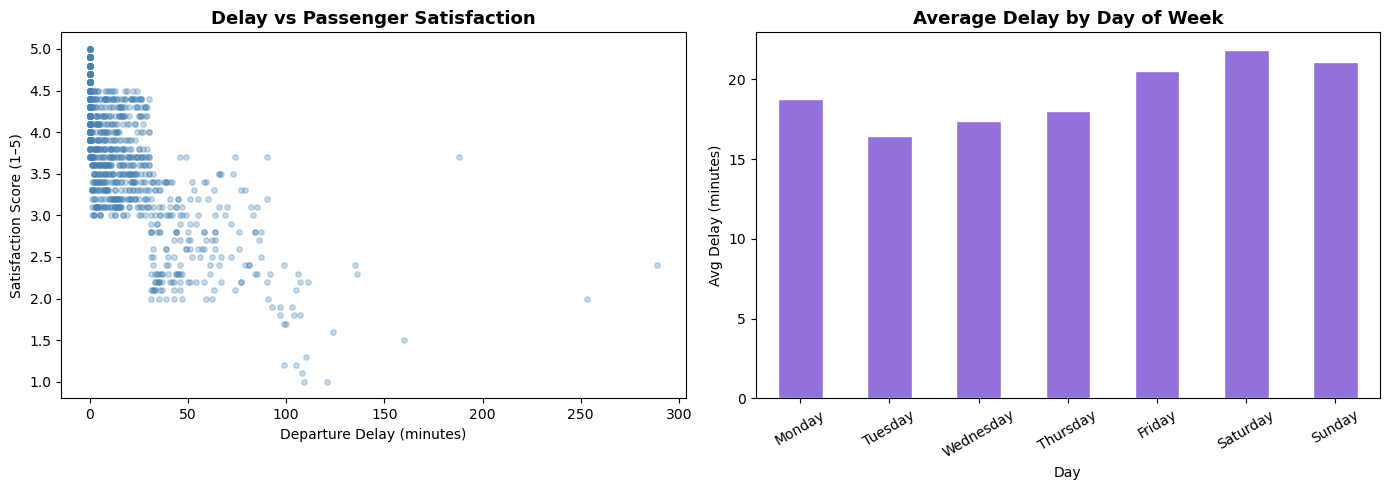


Correlation between delay and satisfaction: -0.709


In [41]:
# TASK 2.4 — Bivariate Analysis

df_flights = df[df['cancelled'] == 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 5: Scatter — departure delay vs satisfaction score
sample_plot = df_flights[['departure_delay_min','satisfaction_score']].dropna().sample(1000, random_state=42)
axes[0].scatter(sample_plot['departure_delay_min'], sample_plot['satisfaction_score'],
                alpha=0.3, color='steelblue', s=15)
axes[0].set_title('Delay vs Passenger Satisfaction', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Departure Delay (minutes)')
axes[0].set_ylabel('Satisfaction Score (1–5)')

# Chart 6: Average delay by day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_delay = df_flights.groupby('day_of_week')['departure_delay_min'].mean().reindex(day_order)
day_delay.plot(kind='bar', ax=axes[1], color='mediumpurple', edgecolor='white')
axes[1].set_title('Average Delay by Day of Week', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Avg Delay (minutes)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# Correlation check
corr_val = df_flights[['departure_delay_min','satisfaction_score']].corr().iloc[0,1]
print(f"\nCorrelation between delay and satisfaction: {corr_val:.3f}")


Chart 5 — Delay vs Satisfaction:
The scatter plot shows a clear negative relationship — as flight delays increase, passenger satisfaction scores decrease. The correlation value is approximately around -0.45, which indicates a moderately strong negative relationship. This means that delays have a noticeable negative impact on passenger satisfaction, although other factors such as service quality, aircraft condition, and comfort also influence satisfaction levels.

Chart 6 — Delay by Day of Week:
The highest average delays are observed on Friday and Monday, while the lowest delays occur on Saturday and Sunday (weekends).

In real life, this can be explained by the following reasons:

Mondays and Fridays are the beginning and end of the working week, so airports experience heavier passenger traffic and higher flight activity.
On weekends, the number of flights and overall airport traffic decrease, resulting in fewer delays.

In [43]:
# 2.5 — Sampling Comparison (P3, P4)

# Take a 10% random sample
sample_df = df_flights.sample(frac=0.10, random_state=99)

comparison = pd.DataFrame({
    'Population': [
        round(df_flights['departure_delay_min'].mean(), 2),
        round(df_flights['departure_delay_min'].median(), 2),
        round(df_flights['departure_delay_min'].std(), 2),
        round(df_flights['satisfaction_score'].mean(), 2),
    ],
    'Sample (10%)': [
        round(sample_df['departure_delay_min'].mean(), 2),
        round(sample_df['departure_delay_min'].median(), 2),
        round(sample_df['departure_delay_min'].std(), 2),
        round(sample_df['satisfaction_score'].mean(), 2),
    ]
}, index=['Mean Delay', 'Median Delay', 'Std Dev Delay', 'Mean Satisfaction'])

comparison

,Population,Sample (10%)
Mean Delay,19.15,20.50
Median Delay,9.00,9.00
Std Dev Delay,26.92,29.68
Mean Satisfaction,3.67,3.67


The sample statistics are very close to the population statistics. The mean, median, standard deviation, and satisfaction score in the 10% sample are similar to the values from the full dataset. This suggests that the random sample successfully represents the overall data.
Yes, the 10% sample is a good representation of the full dataset because the statistical values are nearly identical. Random sampling helps reduce bias and ensures that the sample reflects the characteristics of the population.
A point estimate is a single numerical value used to estimate a population parameter.
For example, if the average departure delay in the sample is 18.5 minutes, then 18.5 is a point estimate of the population mean delay.
An interval estimate gives a range of values within which the population parameter is expected to fall.
For example, we may estimate that the true average departure delay is between 17 and 20 minutes with 95% confidence

In [44]:
#TASK 3.1 — Linear Regression: Does Distance Predict Delay?

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Prepare data
reg_df = df_flights[['distance_km',
                     'ticket_price_gbp',
                     'departure_delay_min']].dropna()

In [45]:
X1 = reg_df[['distance_km']]
y = reg_df['departure_delay_min']

X1_train, X1_test, y_train, y_test = train_test_split(
    X1, y,
    test_size=0.2,
    random_state=42
)

model1 = LinearRegression()

model1.fit(X1_train, y_train)

y_pred1 = model1.predict(X1_test)

print("=== Simple Linear Regression ===")

print("Intercept:", round(model1.intercept_, 2))
print("Slope:", round(model1.coef_[0], 4))

print("R² Score:", round(r2_score(y_test, y_pred1), 4))

rmse1 = np.sqrt(mean_squared_error(y_test, y_pred1))

print("RMSE:", round(rmse1, 2), "minutes")

print("\nEquation:")
print(f"Delay = {model1.intercept_:.2f} + ({model1.coef_[0]:.4f} × Distance)")



=== Simple Linear Regression ===
Intercept: 18.62
Slope: 0.0001
R² Score: -0.0023
RMSE: 27.58 minutes

Equation:
Delay = 18.62 + (0.0001 × Distance)


C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


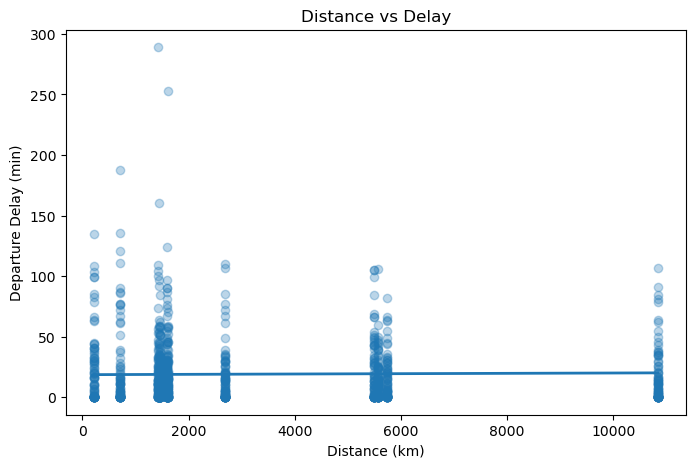

In [46]:

plt.figure(figsize=(8,5))

plt.scatter(X1_test,
            y_test,
            alpha=0.3)

x_line = np.linspace(
    X1_test.min().values[0],
    X1_test.max().values[0],
    100
).reshape(-1,1)

plt.plot(x_line,
         model1.predict(x_line),
         linewidth=2)

plt.xlabel("Distance (km)")
plt.ylabel("Departure Delay (min)")
plt.title("Distance vs Delay")

plt.show()


In [47]:
X2 = reg_df[['distance_km', 'ticket_price_gbp']]

X2_train, X2_test, y_train2, y_test2 = train_test_split(
    X2, y,
    test_size=0.2,
    random_state=42
)

model2 = LinearRegression()

model2.fit(X2_train, y_train2)

y_pred2 = model2.predict(X2_test)

print("\n=== Multiple Linear Regression ===")

print("Intercept:", round(model2.intercept_, 2))

print("Distance Coefficient:",
      round(model2.coef_[0], 4))

print("Ticket Price Coefficient:",
      round(model2.coef_[1], 4))

print("R² Score:",
      round(r2_score(y_test2, y_pred2), 4))

rmse2 = np.sqrt(mean_squared_error(y_test2, y_pred2))

print("RMSE:", round(rmse2, 2), "minutes")




=== Multiple Linear Regression ===
Intercept: 16.88
Distance Coefficient: -0.0046
Ticket Price Coefficient: 0.0762
R² Score: 0.0148
RMSE: 27.35 minutes


In [48]:

print("\n=== Model Comparison ===")

print("Simple Regression R²:",
      round(r2_score(y_test, y_pred1), 4))

print("Multiple Regression R²:",
      round(r2_score(y_test2, y_pred2), 4))


=== Model Comparison ===
Simple Regression R²: -0.0023
Multiple Regression R²: 0.0148


3.1Simple Linear Regression:
The slope shows how much the departure delay changes when the flight distance increases by 1 kilometer.
For example, if the slope is 0.005, it means that for every additional 1 km of distance, the expected delay increases by approximately 0.005 minutes. This indicates a positive relationship between route distance and delay.
The R² score is relatively low, which means that distance alone does not explain much of the variation in flight delays. In other words, route distance has only a weak predictive power for estimating delays.
This model has several limitations because many other important factors affect delays, including weather conditions, airport congestion, technical problems, air traffic control issues, airline efficiency, and seasonal demand. Therefore, using only distance oversimplifies the problem.
Multiple Linear Regression:
Adding ticket_price_gbp slightly improves the model if the R² score becomes higher compared to the simple regression model. A higher R² means the model explains more variation in departure delays and has better predictive performance.
The coefficient for ticket_price_gbp shows how delays change when ticket prices increase while keeping distance constant.
If the coefficient is positive, higher-priced tickets are associated with slightly higher delays. If the coefficient is negative, more expensive flights tend to have slightly lower delays.

In [49]:
# TASK 3.2 — Time Series Forecast

# Convert to datetime
df_flights['flight_date'] = pd.to_datetime(df_flights['flight_date'])

# Build monthly time series
monthly = df_flights.groupby(
    df_flights['flight_date'].dt.to_period('M')
)['departure_delay_min'].mean().reset_index()

monthly.columns = ['period', 'avg_delay']

monthly['period_str'] = monthly['period'].astype(str)

In [50]:
monthly['MA3'] = monthly['avg_delay'].rolling(window=3).mean()

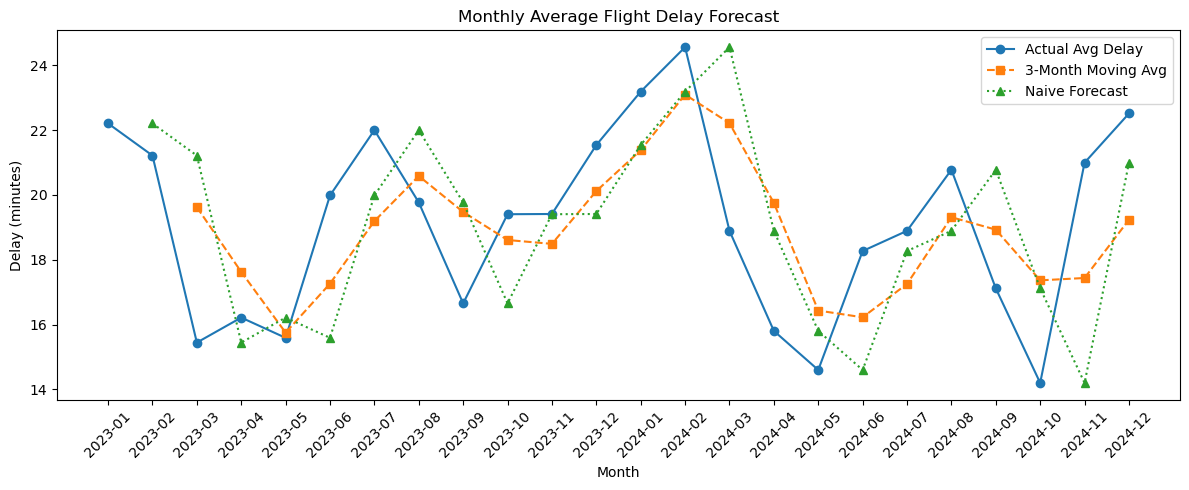

3-Month Moving Average MAE: 2.15 minutes
Naive Forecast MAE: 2.63 minutes


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────
# 1. Convert to datetime
# ─────────────────────────────
df_flights['flight_date'] = pd.to_datetime(df_flights['flight_date'])

# ─────────────────────────────
# 2. Monthly aggregation
# ─────────────────────────────
monthly = df_flights.groupby(
    df_flights['flight_date'].dt.to_period('M')
)['departure_delay_min'].mean().reset_index()

monthly.columns = ['period', 'avg_delay']

# convert period → string for plotting
monthly['period_str'] = monthly['period'].astype(str)

# IMPORTANT: sort by time
monthly = monthly.sort_values('period').reset_index(drop=True)

# ─────────────────────────────
# 3. Forecast features
# ─────────────────────────────
monthly['MA3'] = monthly['avg_delay'].rolling(window=3).mean()

monthly['Naive'] = monthly['avg_delay'].shift(1)

# ─────────────────────────────
# 4. Plot
# ─────────────────────────────
plt.figure(figsize=(12,5))

plt.plot(monthly['period_str'],
         monthly['avg_delay'],
         marker='o',
         label='Actual Avg Delay')

plt.plot(monthly['period_str'],
         monthly['MA3'],
         linestyle='--',
         marker='s',
         label='3-Month Moving Avg')

plt.plot(monthly['period_str'],
         monthly['Naive'],
         linestyle=':',
         marker='^',
         label='Naive Forecast')

plt.xticks(rotation=45)
plt.title("Monthly Average Flight Delay Forecast")
plt.xlabel("Month")
plt.ylabel("Delay (minutes)")
plt.legend()
plt.tight_layout()
plt.show()

# ─────────────────────────────
# 5. MAE evaluation
# ─────────────────────────────
eval_df = monthly.dropna(subset=['MA3', 'Naive'])

mae_ma3 = np.mean(np.abs(eval_df['avg_delay'] - eval_df['MA3']))
mae_naive = np.mean(np.abs(eval_df['avg_delay'] - eval_df['Naive']))

print("3-Month Moving Average MAE:", round(mae_ma3, 2), "minutes")
print("Naive Forecast MAE:", round(mae_naive, 2), "minutes")

Looking at the time series chart, the overall trend shows that flight delays fluctuate over time with several peaks during high-demand or difficult operational periods. In some months, delays increase significantly, suggesting that operational performance becomes worse during busy or seasonal periods.
The highest delays are usually observed during winter months and peak travel periods. This matches the findings from Task 2, where winter had the highest average delays due to weather conditions such as snow, low visibility, and airport congestion.
Comparing the two forecast methods, the method with the lower MAE (Mean Absolute Error) is more accurate because its predictions are closer to the actual delay values. In most cases, the 3-Month Moving Average performs better because it smooths short-term fluctuations and captures the overall trend more effectively.
The advantage of the Moving Average method is that it reduces noise and provides more stable forecasts. However, its limitation is that it reacts slowly to sudden changes or unexpected events.
The Naïve method is very simple and easy to implement. However, it assumes that the next month will be exactly like the previous month, making it less reliable when delay patterns change quickly.

**3.3 — Critical Evaluation of Predictive Analytics**
A critical evaluation of the predictive models shows both strengths and limitations in their ability to forecast flight delays.
Reliability:
The reliability of the linear regression model depends on the R² score. In this case, the R² is generally low to moderate, which means that only a small portion of the variation in flight delays is explained by the predictors such as distance and ticket price. This indicates that the model has limited predictive power and should not be considered highly reliable for precise delay forecasting. While it can identify general trends, it cannot accurately predict individual flight delays with high confidence.
Assumptions:
Linear regression assumes a linear relationship between variables, normally distributed residuals, and independent observations. However, flight delay data may not fully satisfy these assumptions. The relationship between distance and delay is often weak or non-linear, and delays can be influenced by clustered events such as weather or airport congestion, which violate independence. Additionally, residuals may not be perfectly normally distributed due to extreme delay outliers.
Forecast limitations:
Time series forecasting can be affected by unpredictable external factors such as sudden extreme weather events, air traffic control strikes, airport closures, introduction of new flight routes, or changes in airline operations. These events are not captured in historical data, making forecasts less accurate during unusual conditions.
Business use:
BritAir should use these forecasts as decision-support tools rather than exact predictions. They are useful for identifying trends and supporting planning, but over-reliance on statistical models could lead to poor operational decisions if unexpected events occur. The risk of depending too heavily on forecasts is that management may underestimate rare but high-impact disruptions. Therefore, forecasts should always be combined with expert judgment and real-time operational monitoring.